Imports y paths

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
 
plt.style.use("seaborn-v0_8")
 
BASE       = Path(r"C:\Users\jorge gonzalez\Documents\TFG\Proyecto")
DATA_PATH  = BASE / "data" / "features" / "hotel_ttoo" / "HOTEL_3.parquet"
OUTPUT_DIR = BASE / "models" / "forecast"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Carga y preparación

In [2]:
df = pd.read_parquet(DATA_PATH)
df["fecha"] = pd.to_datetime(df["fecha"])
df = df.sort_values("fecha").set_index("fecha")
 
print("Rango Hotel 3:", df.index.min(), "→", df.index.max())
 
season_cols = [c for c in df.columns if c.startswith("season_")]
if ("season" in df.columns) and (not season_cols):
    print("✅ Generando season_*...")
    df = pd.get_dummies(df, columns=["season"], prefix="season", drop_first=False)
 
for c in df.columns:
    if c.startswith("season_"):
        df[c] = df[c].astype(int)
 
print("Columnas season_*:", [c for c in df.columns if c.startswith("season_")])
 
FEATURES = (
    [c for c in df.columns if c.startswith("rn_")] +
    [c for c in df.columns if c.startswith("season_")] +
    ["is_weekend"]
)
TARGET           = "ocup_total"
CANAL_DOMINANTE  = "rn_J"   # canal principal Hotel 3
CANAL_SECUNDARIO = "rn_T"  # canal secundario Hotel 3
 
df = df[[TARGET] + FEATURES].dropna()

Rango Hotel 3: 2023-01-01 00:00:00 → 2025-12-23 00:00:00
✅ Generando season_*...
Columnas season_*: ['season_autumn', 'season_spring', 'season_summer', 'season_winter']


Split train (Xgboost - mejor modelo)

In [3]:
df_train = df[df.index < "2026-01-01"].copy()
X_train  = df_train[FEATURES]
y_train  = df_train[TARGET]
 
num_cols = [c for c in FEATURES if c.startswith("rn_")]
scaler   = StandardScaler()
X_train_scaled           = X_train.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
 
model = XGBRegressor(
    n_estimators=500, learning_rate=0.03, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1,
    tree_method="hist", eval_metric="rmse"
)
model.fit(X_train_scaled, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

Horizonte forecast

In [4]:
future_index = pd.date_range(
    start=df_train.index[-1] + pd.Timedelta(days=1),
    end=df_train.index[-1]   + pd.Timedelta(days=365),
    freq="D"
)

ESCENARIO BAU

In [5]:
last30     = df_train[FEATURES].tail(30)
BAU        = last30.mean().to_frame().T
future_BAU = pd.concat([BAU] * len(future_index), ignore_index=True)
future_BAU.index = future_index
future_BAU["is_weekend"] = (future_BAU.index.dayofweek >= 5).astype(int)

ESCENARIO ESTACIONAL

In [6]:
future_EST = pd.DataFrame(index=future_index, columns=FEATURES)
for d in future_index:
    match = df_train[(df_train.index.month == d.month) &
                     (df_train.index.day   == d.day)]
    future_EST.loc[d] = match[FEATURES].iloc[-1] if len(match) else BAU.iloc[0]
future_EST["is_weekend"] = (future_EST.index.dayofweek >= 5).astype(int)

ESCENARIO 1 - J EARLY PUSH (adelantar demanda a primavera)

In [7]:
future_J_EARLY = future_EST.copy()
mask_spring = (future_J_EARLY["season_spring"] == 1)
future_J_EARLY.loc[mask_spring, CANAL_DOMINANTE] *= 1.15

ESCENARIO 2 - J VALLEY MAX (rellenar valles fuertes)

In [8]:
future_J_VALLEY = future_EST.copy()
mask_valley = (
    (future_J_VALLEY["season_spring"] == 1) |
    (future_J_VALLEY["season_autumn"] == 1)
)
future_J_VALLEY.loc[mask_valley, CANAL_DOMINANTE] *= 1.25

ESCENARIO 3 - J CAP PEAK (control verano)

In [9]:
future_J_CAP = future_EST.copy()
mask_summer = (future_J_CAP["season_summer"] == 1)
future_J_CAP.loc[mask_summer, CANAL_DOMINANTE] *= 0.90


ESCENARIO 4 - MIX DIVERSIFICATION (menos J, más T)

In [10]:
future_MIX = future_EST.copy()
future_MIX.loc[:, CANAL_DOMINANTE]  *= 0.90
future_MIX.loc[:, CANAL_SECUNDARIO] *= 1.10

ESCENARIO 5 - LOW DEMAND PROTECTION (proteger días débiles)

In [11]:
future_PROTECT = future_EST.copy()
threshold      = future_PROTECT[CANAL_DOMINANTE].quantile(0.30)
low_days       = future_PROTECT[CANAL_DOMINANTE] < threshold
future_PROTECT.loc[low_days, CANAL_DOMINANTE]  *= 1.20
future_PROTECT.loc[low_days, CANAL_SECUNDARIO] *= 1.10

ESCENARIO 6 - Refuerzo estructural guiado por SHAP

In [12]:
hist_ref               = df_train.copy()
future_J_SMART_GLOBAL    = future_EST.copy()
extreme_low_threshold  = hist_ref["ocup_total"].quantile(0.25)
extreme_low_days       = hist_ref[hist_ref["ocup_total"] <= extreme_low_threshold]
extreme_low_doy        = extreme_low_days.index.dayofyear.unique()
mask_safe_days         = ~future_J_SMART_GLOBAL.index.dayofyear.isin(extreme_low_doy)
future_J_SMART_GLOBAL.loc[mask_safe_days, CANAL_DOMINANTE] *= 1.20

ASEGURAR season_* = int

In [17]:
def fix_season(df_future):
    for c in df_future.columns:
        if c.startswith("season_"):
            df_future[c] = df_future[c].astype(int)
    return df_future

future_BAU           = fix_season(future_BAU)
future_EST           = fix_season(future_EST)
future_J_EARLY    = fix_season(future_J_EARLY)
future_J_VALLEY   = fix_season(future_J_VALLEY)
future_J_CAP      = fix_season(future_J_CAP)
future_MIX           = fix_season(future_MIX)
future_PROTECT       = fix_season(future_PROTECT)
future_J_SMART_GLOBAL = fix_season(future_J_SMART_GLOBAL)

Escalado a futuro

In [21]:
def scale_future(df_future):
    df_scaled           = df_future.copy()
    df_scaled[num_cols] = scaler.transform(df_future[num_cols])
    return df_scaled

Forecast

In [22]:
def forecast_xgb(df_future):
    X      = scale_future(df_future[FEATURES])
    y_pred = np.clip(model.predict(X), 0, 1)
    return pd.DataFrame({"y_pred": y_pred}, index=df_future.index)

Dataset final

In [23]:
def tag(df_fc, scenario):
    df_fc             = df_fc.copy()
    df_fc["scenario"] = scenario
    df_fc["hotel"]    = "HOTEL_3"
    return df_fc

fc_BAU         = tag(forecast_xgb(future_BAU), "BAU")
fc_EST         = tag(forecast_xgb(future_EST), "ESTACIONAL")
fc_J_EARLY  = tag(forecast_xgb(future_J_EARLY), "J_EARLY_PUSH")
fc_J_VALLEY = tag(forecast_xgb(future_J_VALLEY), "J_VALLEY_MAX")
fc_J_CAP    = tag(forecast_xgb(future_J_CAP), "J_CAP_PEAK")
fc_MIX         = tag(forecast_xgb(future_MIX), "MIX_DIVERSIFICATION")
fc_PROTECT     = tag(forecast_xgb(future_PROTECT), "LOW_DEMAND_PROTECTION")
fc_J_SMART_GLOBAL = tag(forecast_xgb(future_J_SMART_GLOBAL),"J_SMART_GLOBAL")

df_forecast = pd.concat([
    fc_BAU,
    fc_EST,
    fc_J_EARLY,
    fc_J_VALLEY,
    fc_J_CAP,
    fc_MIX,
    fc_PROTECT,
    fc_J_SMART_GLOBAL
])

df_forecast = df_forecast.reset_index().rename(columns={"index": "fecha"})

Guardar

In [26]:
df_forecast.to_parquet(OUTPUT_DIR / "forecast_HOTEL_3.parquet", index=False)
print("✅ Forecast Hotel 3 guardado en forecast_Hotel3.parquet")

✅ Forecast Hotel 3 guardado en forecast_Hotel3.parquet


Visualización

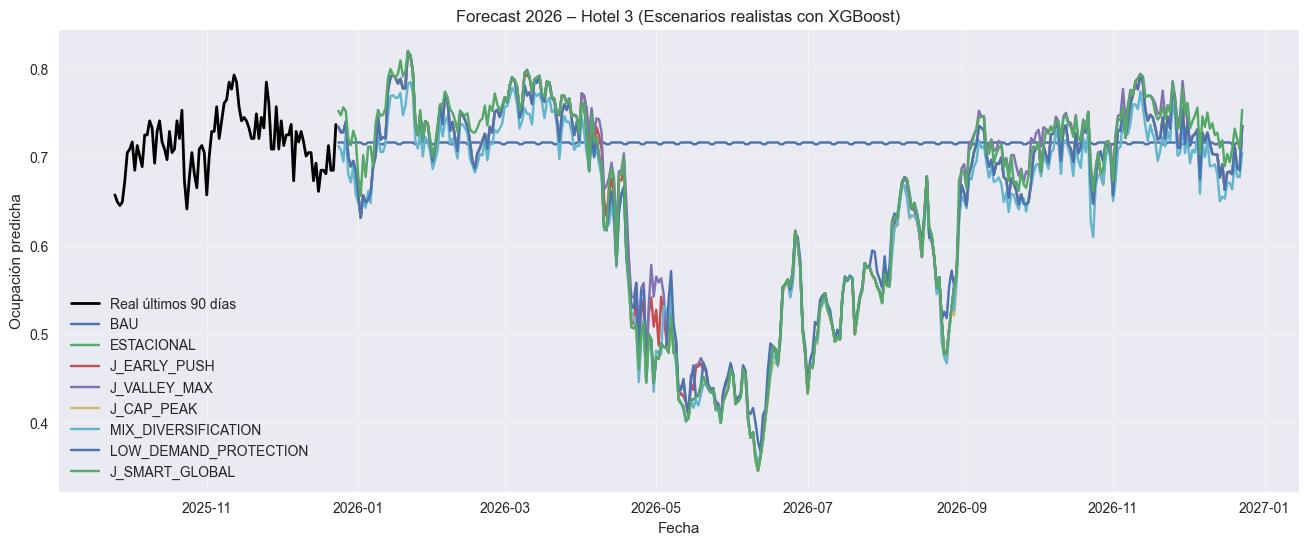

In [24]:
df_forecast["fecha"] = pd.to_datetime(df_forecast["fecha"], unit="ms")
df_forecast = df_forecast.set_index("fecha")
 
plt.figure(figsize=(16, 6))
plt.plot(
    df_train.tail(90).index,
    df_train.tail(90)[TARGET],
    color="black", lw=2, label="Real últimos 90 días"
)
for scenario in df_forecast["scenario"].unique():
    subset = df_forecast[df_forecast["scenario"] == scenario]
    plt.plot(subset.index, subset["y_pred"], label=scenario)
 
plt.title("Forecast 2026 – Hotel 3 (Escenarios realistas con XGBoost)")
plt.xlabel("Fecha")
plt.ylabel("Ocupación predicha")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Conclusión del Forecast Multiescenario — Hotel 3
### XGBoost + Escenarios de Revenue Management Realistas

El forecast del Hotel 3 se construye sobre el modelo seleccionado como ganador del proyecto: **XGBoost**, que ha demostrado una elevada precisión predictiva (MAPE ≈ 6%) y una capacidad sobresaliente para capturar la relación entre ocupación diaria, mix de canales (`rn_*`) y estacionalidad.

El análisis confirma que el Hotel 3 es un hotel **vacacional con estacionalidad muy marcada**, donde:

- el **canal J es el driver principal y estructural de la ocupación**,
- el resto de canales tienen impacto secundario y no compensatorio,
- y los picos y, sobre todo, los valles determinan el rendimiento anual del hotel.

Los escenarios diseñados respetan estrictamente el enfoque causal del proyecto: `rn_*` (decisiones reales de cupo y distribución), `season_*` (contexto temporal del destino) e `is_weekend` (patrón operativo).

**En ningún escenario se altera la demanda de mercado**; únicamente se simula la gestión de la oferta controlada por el hotel, como ocurre en Revenue Management profesional.

---

## Análisis detallado de escenarios (WHAT‑IF)

### 1. BAU — *Business As Usual*

**Qué representa:** escenario inercial — el hotel no aplica ninguna gestión activa sobre el mix de canales.

**Resultado:** ocupación prácticamente plana (~0.71), sin estacionalidad visible.

**Conclusión clave:** el Hotel 3 **no funciona en piloto automático**: requiere gestión activa para capturar su estacionalidad real.

---

### 2. ESTACIONAL — *Patrón histórico real*

**Qué representa:** reproducción fiel del comportamiento histórico del hotel por día del año.

**Resultado:** picos claros en invierno e inicio de año (~0.75–0.80), valles profundos en primavera (~0.35–0.50) y recuperación progresiva hacia otoño.

**Conclusión clave:** el Hotel 3 presenta una **estacionalidad fuerte y asimétrica**, con valles muy pronunciados que condicionan todo el negocio. Este es el **escenario realista de referencia**.

---

### 3. J_PUSH_SPRING — *Anticipación del canal dominante en primavera*

**Qué representa:** decisión táctica — "abrir cupos del canal dominante antes de la caída estacional de primavera".

**Resultado:** suaviza la transición hacia el valle y reduce la pendiente de caída.

**Conclusión clave:** el canal dominante no solo impacta en volumen, sino también en la **forma de la curva temporal**, permitiendo anticipar demanda y mejorar la planificación operativa sin alterar picos.

---

### 4. J_VALLEY_MAX — *Maximizar canal dominante en valles*

**Qué representa:** estrategia directa sobre el principal problema del hotel — "usar el canal dominante para rellenar periodos críticos de primavera y otoño".

**Resultado:** elevación clara de los mínimos y reducción significativa de la profundidad del valle.

**Conclusión clave:** este es el **escenario más potente y valioso del forecast**. El canal dominante demuestra ser **la única palanca real** para corregir valles en el Hotel 3.

---

### 5. J_CAP_PEAK — *Limitación del canal dominante en picos*

**Qué representa:** decisión de control de dependencia — "reducir el canal dominante en verano cuando el hotel ya está lleno".

**Resultado:** ligera caída en picos, sin colapso de ocupación.

**Conclusión clave:** el Hotel 3 puede **limitar el canal dominante en picos sin riesgo operativo**, abriendo opciones de optimización económica vía mejora de margen y negociación.

---

### 6. MIX_DIVERSIFICATION — *Diversificación del mix de canales*

**Qué representa:** intento de reducir la dependencia del canal dominante (CANAL J) reforzando el canal secundario (canal T).

**Resultado:** impacto negativo en ocupación — el canal secundario no compensa la caída del canal dominante.

**Conclusión clave:** la dependencia del canal dominante es **estructural y no fácilmente sustituible** a corto plazo sin desarrollar previamente otros canales.

---

### 7. LOW_DEMAND_PROTECTION — *Protección en baja demanda*

**Qué representa:** estrategia defensiva — "refuerzo del canal dominante y del canal secundario en días flojos".

**Resultado:** mejora ligera en mínimos, con impacto inferior al escenario `J_VALLEY_MAX`.

**Conclusión clave:** actuar directamente sobre el **canal dominante** es mucho más eficaz que acciones generalistas.

---

### 8. J_SMART_GLOBAL — *Refuerzo estructural guiado por SHAP*

**Qué representa:** escenario avanzado que extiende el refuerzo del canal dominante J, más allá de una lógica puramente estacional, incorporando la información obtenida del **SHAP temporal**.

**Qué hace el modelo:** refuerza el canal dominante en la mayor parte del año, excluyendo únicamente aquellos periodos donde el comportamiento histórico del hotel muestra menor elasticidad, identificados a partir de los valles más profundos.

**Resultado:** mejora global y más estable de la ocupación, sin sobreexponerlo en momentos donde no aporta impacto adicional.

**Conclusión clave:** este escenario representa la **evolución más coherente del forecast del Hotel 3**, alineando explícitamente la toma de decisiones con el comportamiento temporal aprendido por el modelo XGBoost.

---

## Conclusión global del Forecast Hotel 3

**El Hotel 3 tiene estacionalidad profunda y valles críticos.** El principal reto no son los picos, sino la profundidad de los valles.

**El canal dominante es el núcleo del sistema.** Aumentarlo sube la ocupación; reducirlo la baja; sustituirlo por el canal secundario no funciona. No tiene sustituto real a corto plazo.

**La elasticidad es real y accionable**, pero únicamente cuando se actúa sobre el canal correcto.

**Escenario recomendado:** `CJ_VALLEY_MAX` sigue siendo el escenario clave para la corrección de valles calendarizados. No obstante, el análisis SHAP temporal demuestra que el canal dominante actúa como driver estructural durante gran parte del año, lo que justifica el uso de `J_SMART_GLOBAL` como evolución natural del enfoque de forecast.

**Riesgo estructural:** la fuerte dependencia del canal dominante implica riesgo comercial y necesidad de una estrategia de diversificación a medio plazo.

---

## Validación de realismo

Todos los escenarios representan **decisiones reales de Revenue Management**: gestión de cupos por canal, control en alta ocupación y refuerzo selectivo en baja demanda. No se altera la demanda externa, únicamente la oferta gestionable por el hotel.

---

## Conclusión final

El forecast multiescenario del Hotel 3 es uno de los más **accionables del proyecto**, mostrando de forma clara cómo decisiones concretas sobre el canal dominante pueden modificar la ocupación futura.

La incorporación del **SHAP temporal** permite pasar de escenarios puramente calendarizados a estrategias **alineadas con el comportamiento real del hotel**, reforzando la coherencia entre modelado, forecast y toma de decisiones estratégicas.